# Tool-call audit of his.txt

Build the CSV once, from the `material_agent` directory:

```bash
python -m src.workflow_audit.history_parser <his.txt> -o src/workflow_audit/outputs/tool_calls.csv
```

Then run the cells below — they read only `outputs/tool_calls.csv`.

A round = one agent turn. Rounds with no real tool calls (a boss turn, or a worker Q&A turn) appear as a single **placeholder row** with an empty `tool`; `real` below excludes those.

In [21]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("audit_outputs/production_run_27-05-2026_fork_16_07_2026_tool_calls.csv")
real = df[df["tool"].fillna("") != ""]              # exclude zero-tool placeholder rows
all_rounds = sorted(df["round"].unique())
n_empty = int((df["tool"].fillna("") == "").sum())
print(len(real), "real tool calls across", len(all_rounds), "rounds", f"({n_empty} zero-tool rounds)")
df.head()

8545 real tool calls across 750 rounds (5 zero-tool rounds)


,round,session,agent,tool,calc_type,outcome,wait_status,wait_minutes,round_start_h,round_start_raw,line_no
0,1,1,supervisor,inspect_my_canvas,NaN,success,NaN,NaN,0.0,0:00:00.065060.,14
1,1,1,supervisor,read_my_canvas,NaN,success,NaN,NaN,0.0,0:00:00.065060.,28
2,1,1,supervisor,inspect_explog,NaN,success,NaN,NaN,0.0,0:00:00.065060.,43
3,2,1,worker,check_time,NaN,success,NaN,NaN,NaN,NaN,152
4,2,1,worker,arXiv_search,NaN,success,NaN,NaN,NaN,NaN,166


## Session restarts
`session` counts process relaunches: invoke.py writes a "Session started" banner into the log on every launch, including crash recovery, so a restart shows up as `session` incrementing while `round` stays put (or barely moves). The vertical dashed lines added to the round-indexed plots below mark the round each restart resumed into.

In [22]:
session_starts = df.groupby("session")["round"].min()
restart_rounds = session_starts.iloc[1:]   # skip session 1 -- that's round 1, not a restart
print(f"{len(restart_rounds)} restart(s) detected")
display(restart_rounds.rename("round"))

def mark_sessions(ax):
    """Overlay a black line + label at each round a new session (process
    relaunch, incl. crash recovery) resumed into."""
    for session, round_ in restart_rounds.items():
        ax.axvline(round_, color="black", linestyle="--", linewidth=1, alpha=0.7)
        ax.annotate(f"s{session}", (round_, 1), xycoords=("data", "axes fraction"),
                    color="black", fontsize=7, ha="center", va="bottom", annotation_clip=False)

11 restart(s) detected


session
2      57
3      57
4      94
6     144
7     208
8     237
9     238
10    238
11    242
12    707
13    727
Name: round, dtype: int64

In [23]:
ts = (df.dropna(subset=["round_start_h"]).drop_duplicates("round")
        [["round", "round_start_h"]].sort_values("round"))
ts["duration_h"] = ts["round_start_h"].diff().shift(-1)   # duration of each timestamped round

## Per-round × tool counts
Zero-tool rounds appear as all-zero rows (reindexed over every round).

In [24]:
pivot = (real.pivot_table(index="round", columns="tool", values="line_no",
                         aggfunc="count", fill_value=0)
             .reindex(all_rounds, fill_value=0))
display(pivot)

tool,OER_data_analasis_v2,arXiv_search,browse_df,check_time,enter_candidate_in_log,get_candidate_data,get_disposition_info,get_terminations_ranking,inspect_explog,inspect_my_canvas,list_adsorption_sites,query_explog,read_explog,read_my_canvas,search_artifacts,submit_dft_job,update_disposition_info,wait_for_update,write_my_canvas,write_report
round,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0
2,0,5,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
3,0,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0,0
4,2,0,5,0,0,0,0,0,1,1,0,0,0,2,2,0,0,0,2,0
5,0,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,0,0,0,1,0,0,0,0,0,1,0,6,0,2,0,0,0,0,0,1
747,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0
748,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Calls resolved by agent

tool,OER_data_analasis_v2,arXiv_search,browse_df,check_time,enter_candidate_in_log,get_candidate_data,get_disposition_info,get_terminations_ranking,inspect_explog,inspect_my_canvas,list_adsorption_sites,query_explog,read_explog,read_my_canvas,search_artifacts,submit_dft_job,update_disposition_info,wait_for_update,write_my_canvas,write_report
agent,,,,,,,,,,,,,,,,,,,,
supervisor,0,0,0,0,0,0,0,0,104,327,0,857,0,332,0,0,0,0,0,0
worker,55,81,27,180,142,3,570,180,49,20,246,2245,272,131,29,823,502,568,758,44


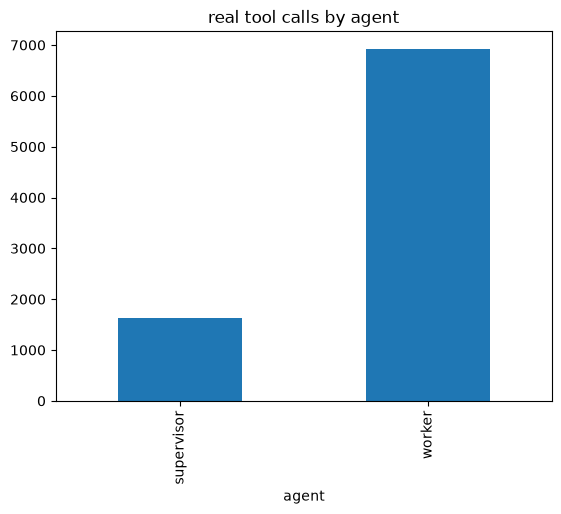

In [25]:
by_agent = real.groupby(["agent", "tool"]).size().unstack(fill_value=0)
display(by_agent)
real.groupby("agent").size().plot.bar(title="real tool calls by agent"); plt.show()

## submit_dft_job: calculation type + outcome

outcome,success
calc_type,
OH_adsorption,110
O_adsorption,311
bulk_relaxation,140
surface_relaxation,161


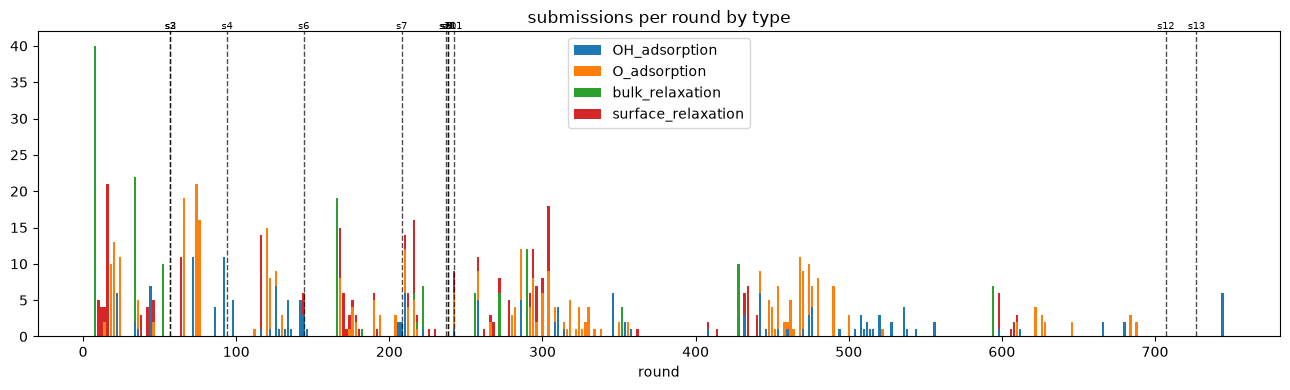

In [26]:
sub = real[real.tool == "submit_dft_job"]
display(sub.groupby(["calc_type", "outcome"]).size().unstack(fill_value=0))
df_sub = sub.groupby(["round", "calc_type"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13, 4))
bottom = pd.Series(0, index=df_sub.index)
for col in df_sub.columns:
    ax.bar(df_sub.index, df_sub[col], bottom=bottom, label=col, width=1.5)
    bottom = bottom + df_sub[col]
ax.set_title("submissions per round by type")
ax.set_xlabel("round")
ax.legend()
mark_sessions(ax)
plt.tight_layout()
plt.ylim([0, 42])
plt.show()

## All tool calls per round (by tool)

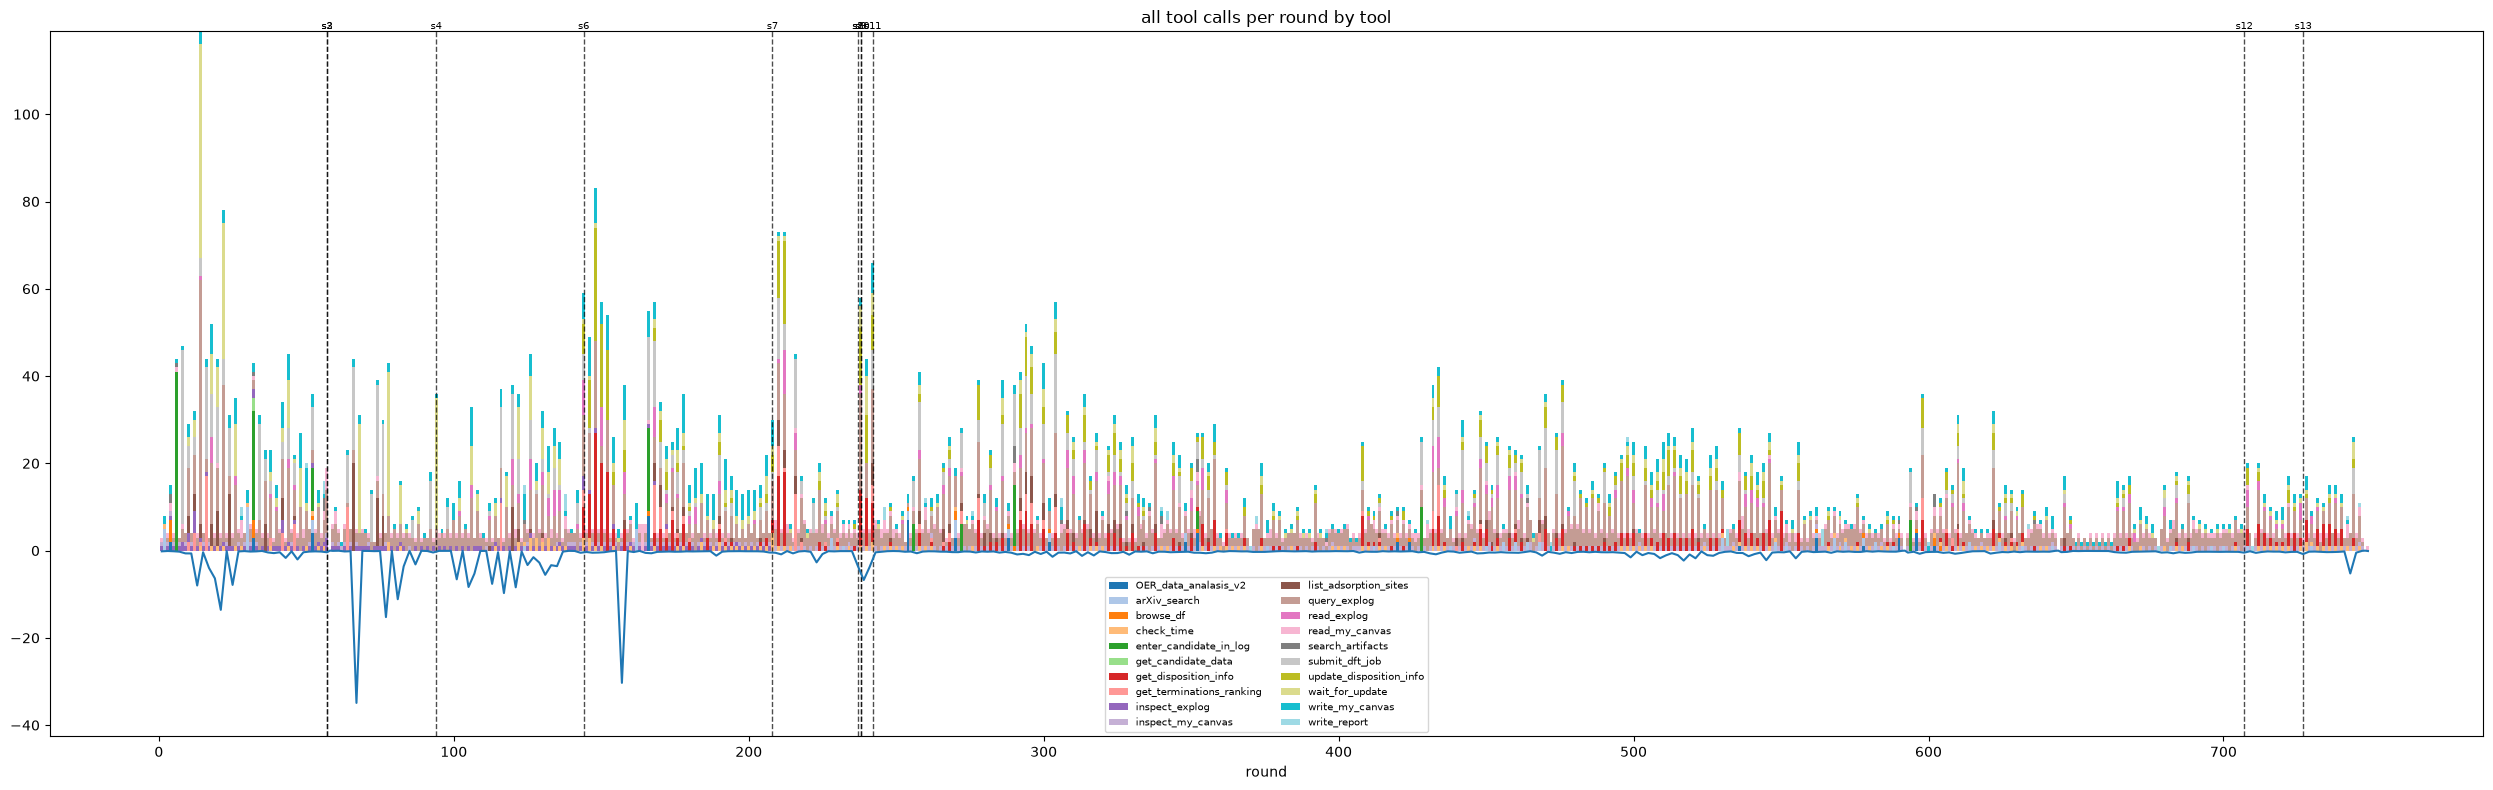

In [27]:
df_tools = (real.groupby(["round", "tool"]).size().unstack(fill_value=0)
                .reindex(all_rounds, fill_value=0))   # every round, zero-tool rounds as 0
colors = plt.cm.tab20.colors
fig, ax = plt.subplots(figsize=(25, 8))
bottom = pd.Series(0, index=df_tools.index)
for i, col in enumerate(df_tools.columns):
    ax.bar(df_tools.index, df_tools[col], bottom=bottom, label=col, width=1, color=colors[i])
    bottom = bottom + df_tools[col]
ax.set_title("all tool calls per round by tool")
ax.set_xlabel("round")
ax.legend(fontsize=7, ncol=2)
mark_sessions(ax)
plt.tight_layout()
# plt.ylim([0, 140])

l1, = ax.plot(ts["round"], -ts["duration_h"], color="tab:blue", label="round duration (h)")

plt.show()

## Outcome / error rate per tool

In [28]:
oc = real.groupby(["tool", "outcome"]).size().unstack(fill_value=0)
oc["error_rate"] = oc.get("error", 0) / oc.sum(axis=1)
display(oc.sort_values("error_rate", ascending=False))

outcome,success,error_rate
tool,,
OER_data_analasis_v2,54,0.0
arXiv_search,81,0.0
browse_df,22,0.0
check_time,180,0.0
enter_candidate_in_log,142,0.0
get_candidate_data,3,0.0
get_disposition_info,570,0.0
get_terminations_ranking,172,0.0
inspect_explog,153,0.0


## Time: round duration & activity
Durations use only timestamped (supervisor/boss) rounds — worker rounds carry no timestamp.

In [29]:
ts

,round,round_start_h,duration_h
0,1,0.000000,0.168333
11,3,0.168333,0.092778
30,5,0.261111,0.149167
78,7,0.410278,0.243889
128,9,0.654167,0.634722
...,...,...,...
8529,745,351.852500,0.471111
8544,747,352.323611,0.058056
8547,748,352.381667,0.008611
8548,749,352.390278,0.098333


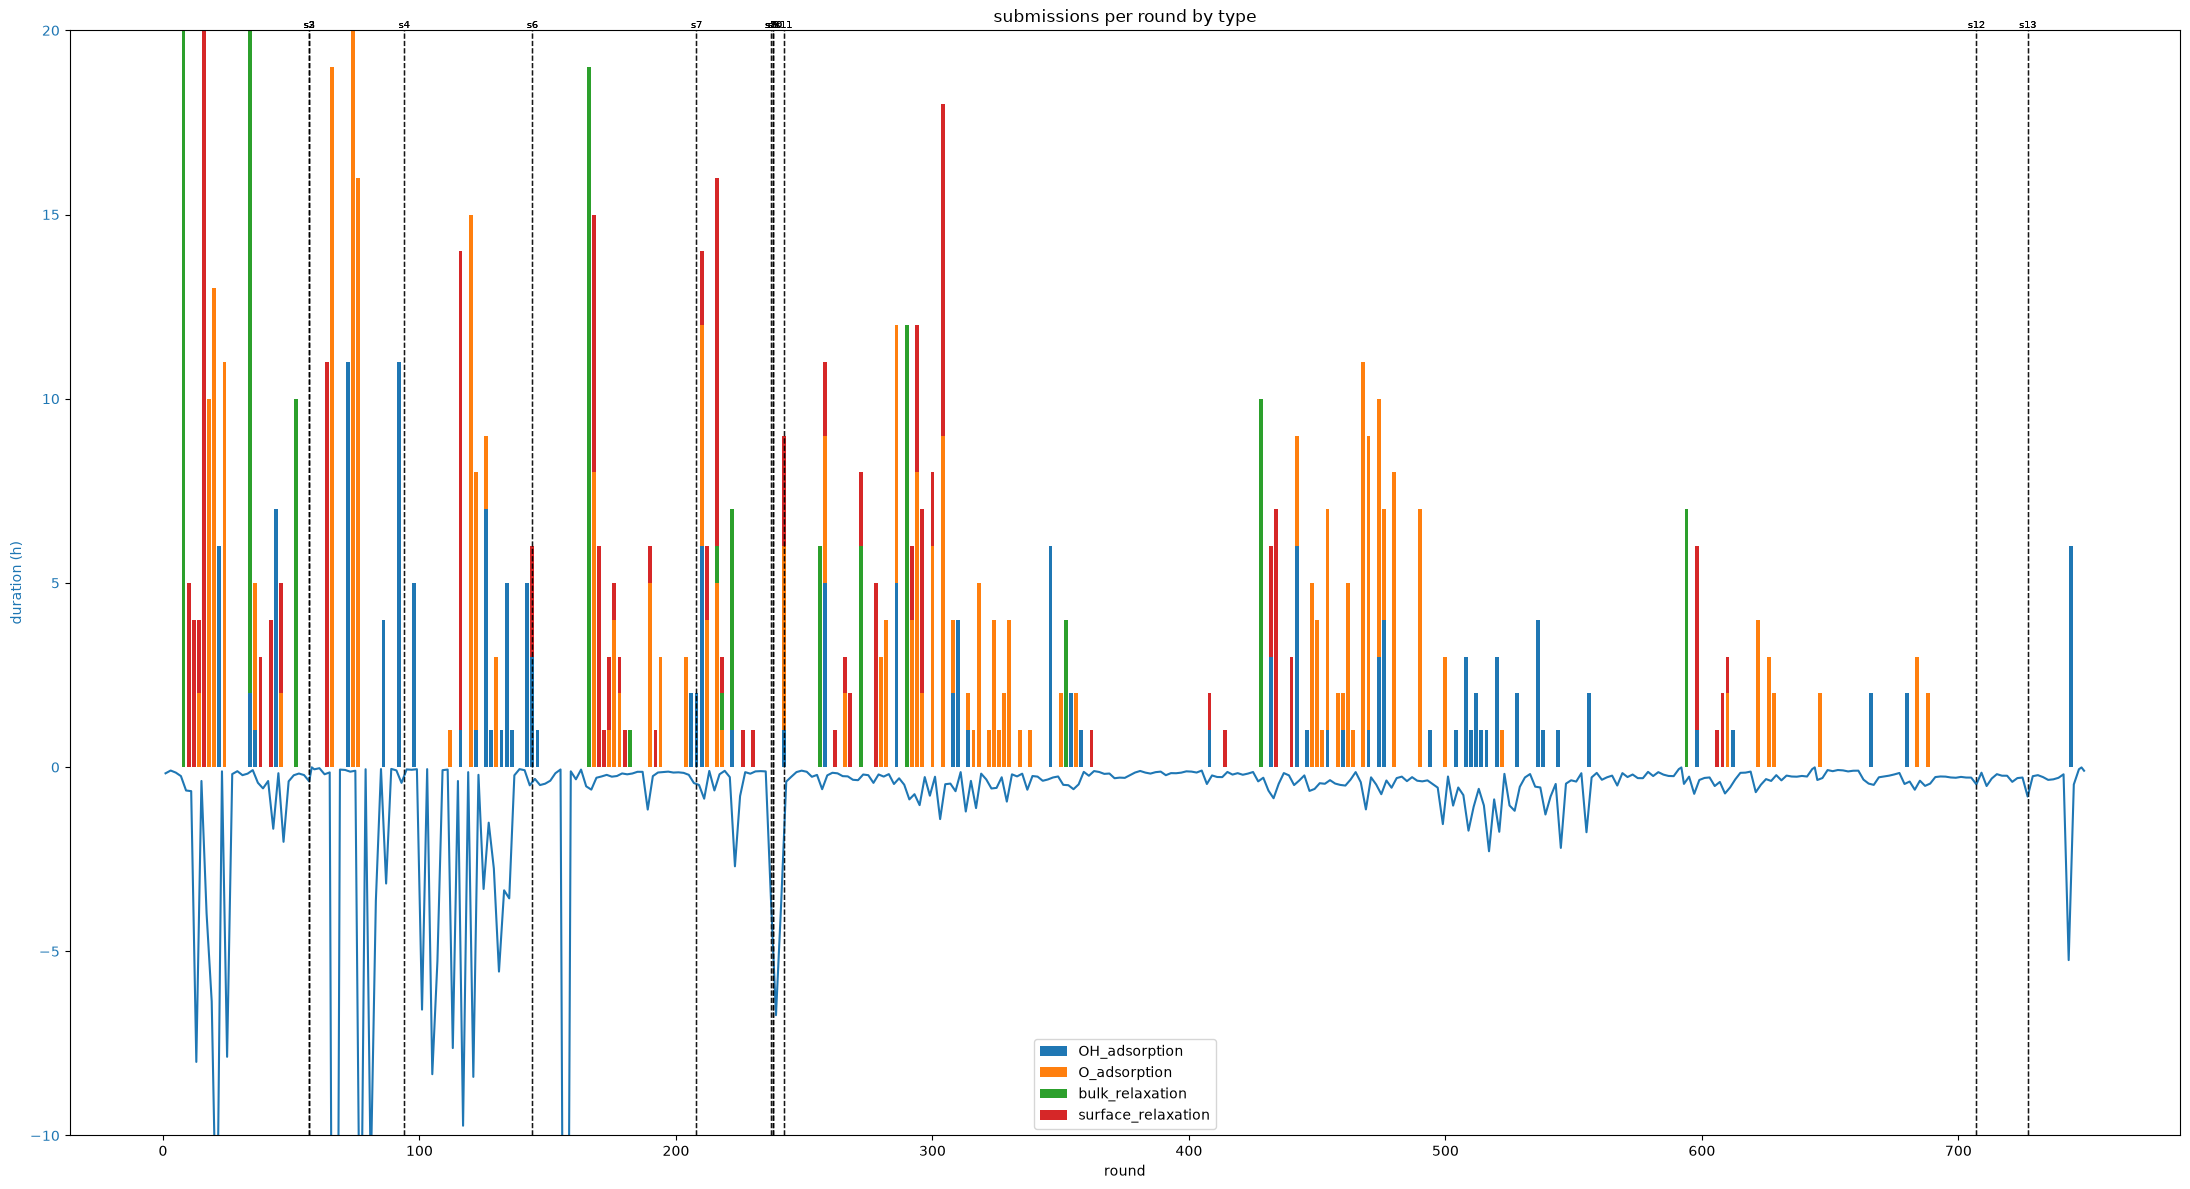

In [30]:
log_scale = False

sub = real[real.tool == "submit_dft_job"]
# display(sub.groupby(["calc_type", "outcome"]).size().unstack(fill_value=0))
df_sub = sub.groupby(["round", "calc_type"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(22, 12))
bottom = pd.Series(0, index=df_sub.index)
for col in df_sub.columns:
    ax.bar(df_sub.index, df_sub[col], bottom=bottom, label=col, width=1.5)
    bottom = bottom + df_sub[col]
ax.set_title("submissions per round by type")
ax.set_xlabel("round")
ax.legend()
mark_sessions(ax)
plt.tight_layout()
# plt.ylim([0, 42])

calls_per_round = real.groupby("round").size()

l1, = ax.plot(ts["round"], -ts["duration_h"], color="tab:blue", label="round duration (h)")
ax.set_xlabel("round")
ax.set_ylabel("duration (h)", color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")
ax.set_ylim([-10, 20])

if log_scale:
    ax.set_yscale("log")
    
mark_sessions(ax)
plt.tight_layout()
plt.show()

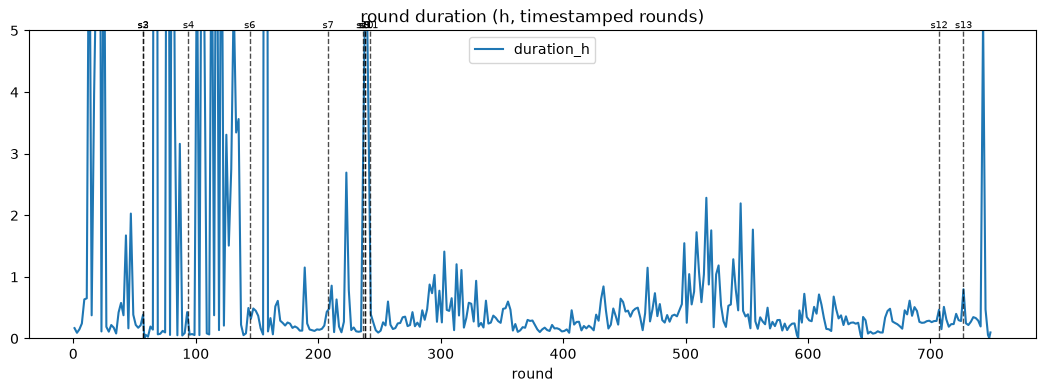

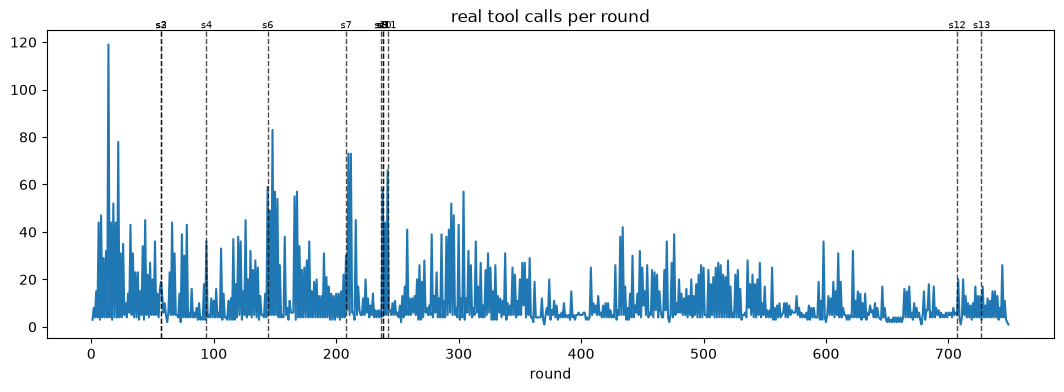

In [31]:
log_scale = False

ax1 = ts.plot(x="round", y="duration_h", figsize=(13, 4), title="round duration (h, timestamped rounds)")
mark_sessions(ax1)
if log_scale:
        plt.yscale("log")

plt.ylim([0, 5])
plt.show()
ax2 = real.groupby("round").size().plot(figsize=(13, 4), title="real tool calls per round")
mark_sessions(ax2)
if log_scale:
    plt.yscale("log")
plt.show()

## Wait logging
`wait_for_update` calls carry a `wait_status` (`waited` / `refused` / `timeout`) and, for `waited`/`timeout`, a `wait_minutes` duration. A round can call `wait_for_update` several times, so the per-round plots below sum `wait_minutes` into a **cumulative wait per round**, shown on a new left-hand axis (the original count axis moves to the right).

wait_status
NaN        7984
waited      402
refused     154
timeout      10
Name: count, dtype: int64


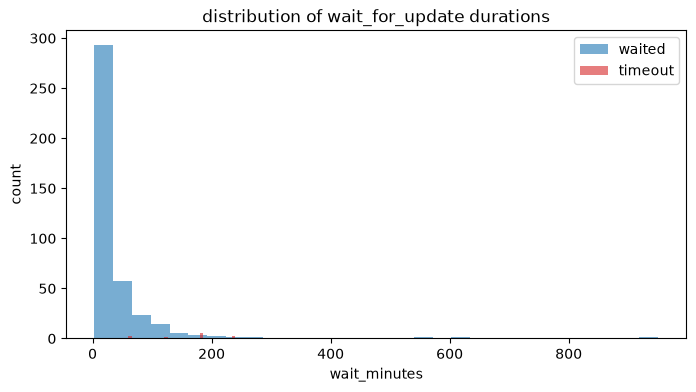

In [32]:
print(df["wait_status"].value_counts(dropna=False))

waits = df[df["wait_status"].isin(["waited", "timeout"])]
fig, ax = plt.subplots(figsize=(8, 4))
for status, color in [("waited", "tab:blue"), ("timeout", "tab:red")]:
    ax.hist(waits.loc[waits.wait_status == status, "wait_minutes"], bins=30, alpha=0.6, label=status, color=color)
ax.set_xlabel("wait_minutes")
ax.set_ylabel("count")
ax.set_title("distribution of wait_for_update durations")
ax.legend()
plt.show()

In [33]:
def align_yaxis(ax1, ax2):
    """Shift ax2's y-limits (keeping its span/resolution) so that 0 sits at
    the same fractional height as 0 does on ax1 -- works whether ax2 is
    inverted or not."""
    y1_lo, y1_hi = ax1.get_ylim()
    y2_lo, y2_hi = ax2.get_ylim()
    frac = (0 - y1_lo) / (y1_hi - y1_lo)
    span2 = y2_hi - y2_lo
    new_lo2 = 0 - frac * span2
    ax2.set_ylim(new_lo2, new_lo2 + span2)

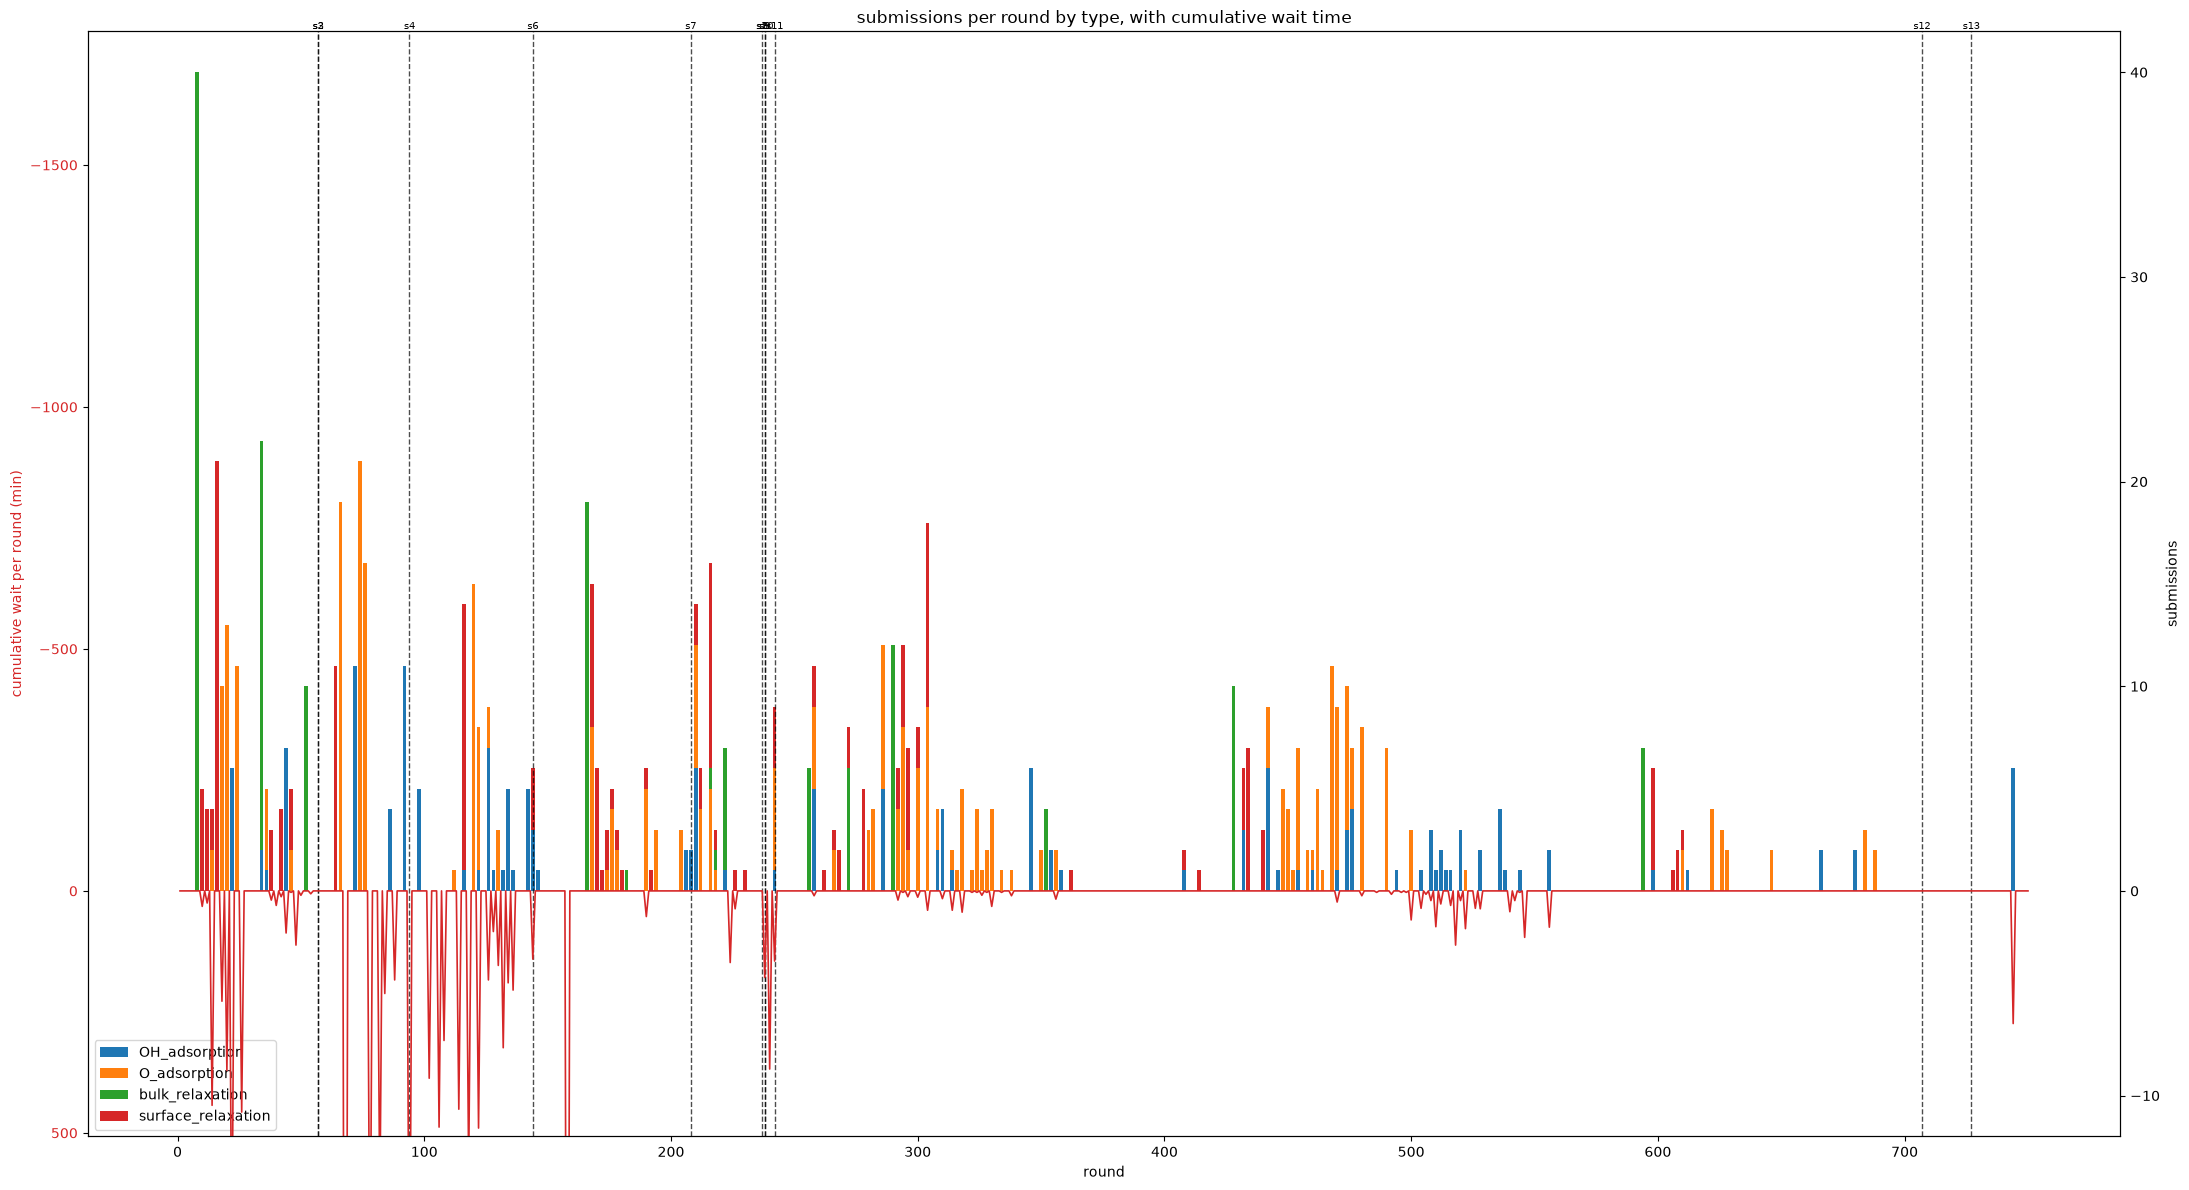

In [37]:
wait_per_round = df.groupby("round")["wait_minutes"].sum().reindex(all_rounds, fill_value=0)

sub = real[real.tool == "submit_dft_job"]
df_sub = sub.groupby(["round", "calc_type"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(22, 12))
bottom = pd.Series(0, index=df_sub.index)
for col in df_sub.columns:
    ax.bar(df_sub.index, df_sub[col], bottom=bottom, label=col, width=1.5)
    bottom = bottom + df_sub[col]
ax.set_title("submissions per round by type, with cumulative wait time")
ax.set_xlabel("round")
ax.set_ylabel("submissions")
ax.legend()
ax.set_ylim(-bottom.max() * 0.3, bottom.max() * 1.05)   # headroom below zero for the wait dip

ax2 = ax.twinx()
ax2.plot(wait_per_round.index, wait_per_round.values, color="tab:red", linewidth=1.2, label="cumulative wait (min)")
ax2.set_ylabel("cumulative wait per round (min)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.yaxis.set_label_position("left")
ax2.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("right")
ax.yaxis.set_ticks_position("right")
ax2.invert_yaxis()      # positive wait values go downward
align_yaxis(ax, ax2)    # line up both axes' zero

mark_sessions(ax)
plt.tight_layout()
plt.show()

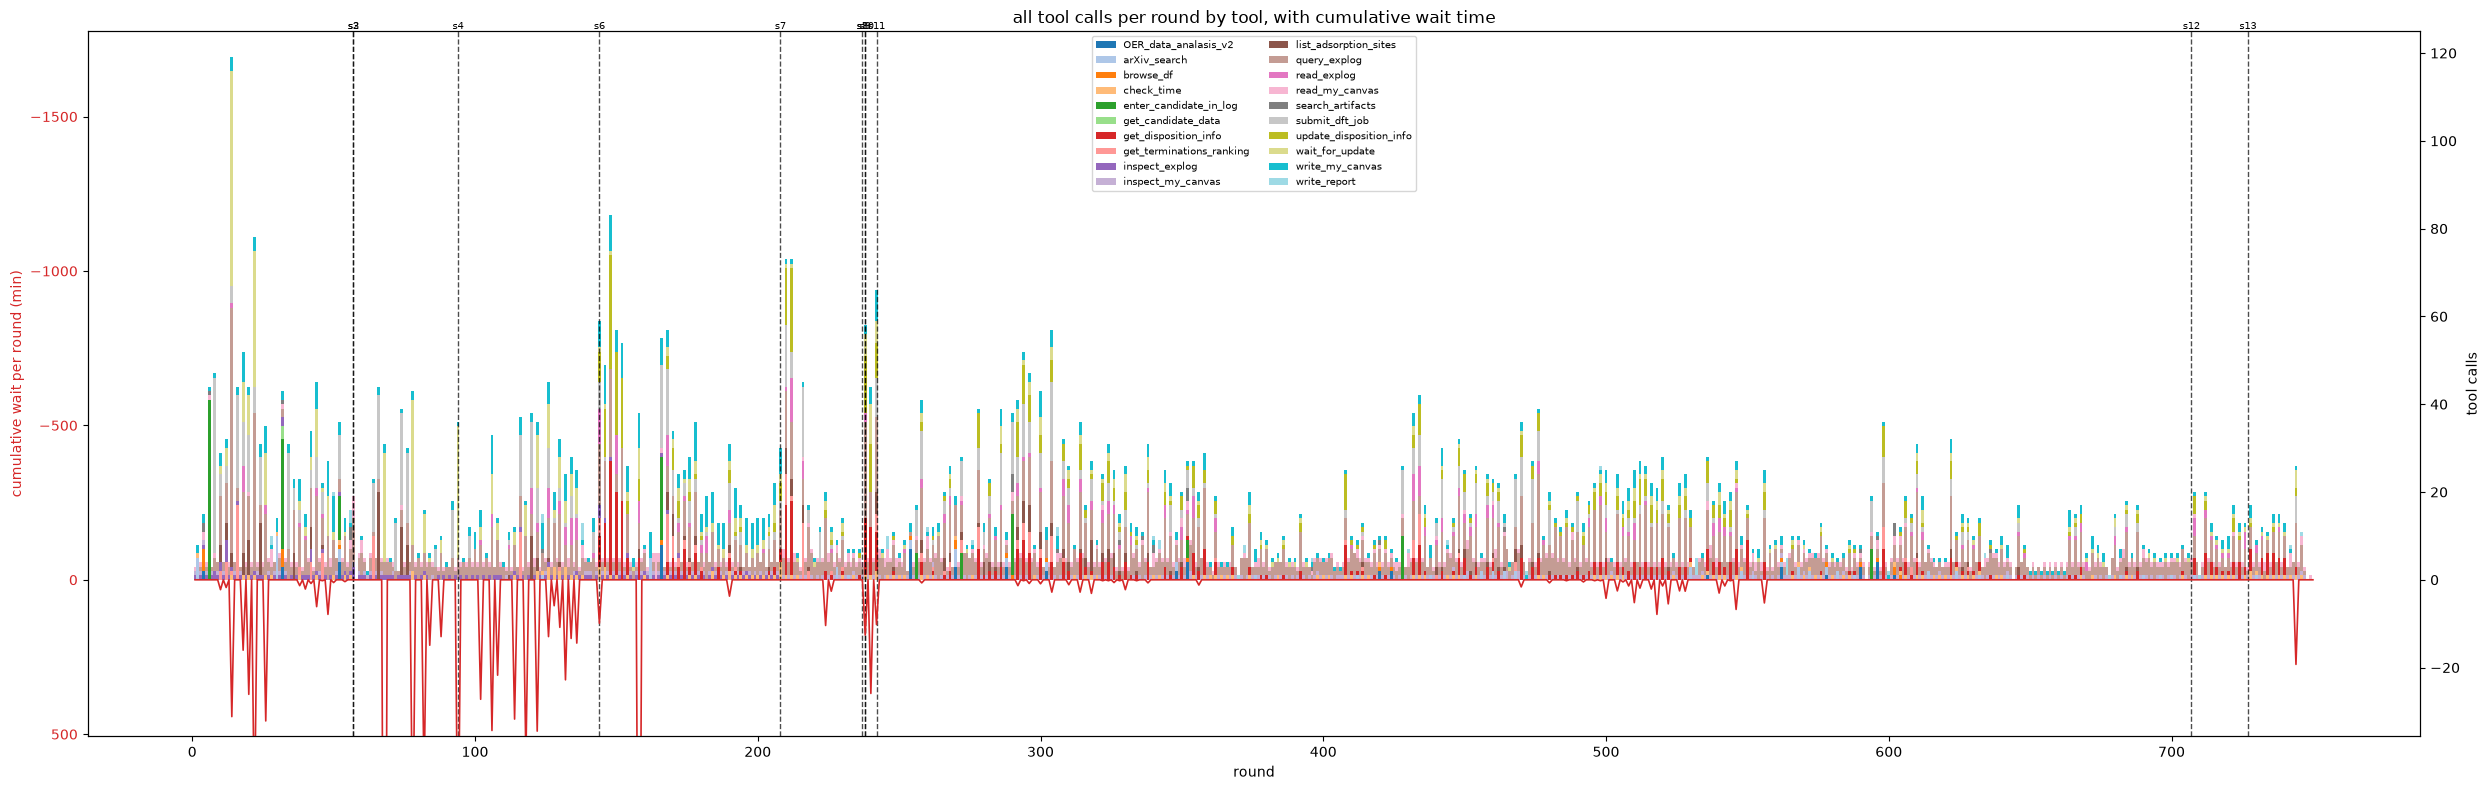

In [35]:
df_tools = (real.groupby(["round", "tool"]).size().unstack(fill_value=0)
                .reindex(all_rounds, fill_value=0))
colors = plt.cm.tab20.colors
fig, ax = plt.subplots(figsize=(25, 8))
bottom = pd.Series(0, index=df_tools.index)
for i, col in enumerate(df_tools.columns):
    ax.bar(df_tools.index, df_tools[col], bottom=bottom, label=col, width=1, color=colors[i])
    bottom = bottom + df_tools[col]
ax.set_title("all tool calls per round by tool, with cumulative wait time")
ax.set_xlabel("round")
ax.set_ylabel("tool calls")
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(-bottom.max() * 0.3, bottom.max() * 1.05)   # headroom below zero for the wait dip

ax2 = ax.twinx()
ax2.plot(wait_per_round.index, wait_per_round.values, color="tab:red", linewidth=1.2, label="cumulative wait (min)")
ax2.set_ylabel("cumulative wait per round (min)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.yaxis.set_label_position("left")
ax2.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("right")
ax.yaxis.set_ticks_position("right")
ax2.invert_yaxis()      # positive wait values go downward
align_yaxis(ax, ax2)    # line up both axes' zero

mark_sessions(ax)
plt.tight_layout()
plt.show()